h(t) = 1/T $\Sigma$ H_n * exp(2pi*I*nt/T)

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Sampling signal, sampling rate 1/dt, max representable freq
# is Nyquist ie f_c = 1/(2dt); if all f < fc then h(t) 
# completely determined by h_n

# Ideally bandpass signal before sampling to ensure no 
# aliasing


Text(0, 0.5, 'y/units')

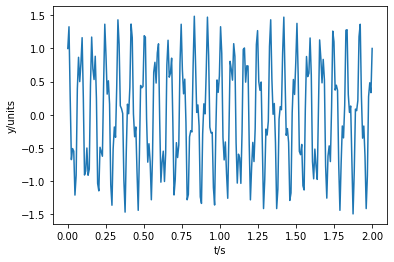

In [44]:
t = 2.0
fftsize = 2**8
dt = t/fftsize
t = np.linspace(0, t, fftsize)
# Generate some fake data at 12Hz and 34Hz
y = np.cos(2*np.pi*12*t) + 0.5*np.sin(2*np.pi*34*t)
plt.plot(t,y)
plt.xlabel("t/s")
plt.ylabel("y/units")

Text(0.5, 0, 'freq/Hz')

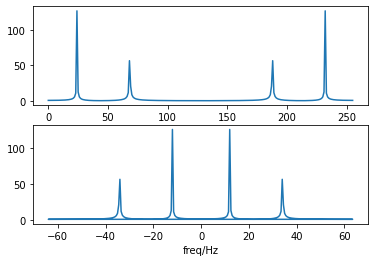

In [45]:
# Negative frequencies come after positive frequencies in the array

Y = np.fft.fft(y)
# FFT modulus vs array index
plt.subplot(2,1,1); plt.plot(abs(Y))
# Correcting freq components
f = np.fft.fftfreq(fftsize, dt)
plt.subplot(2,1,2); plt.plot(f, abs(Y));
plt.xlabel("freq/Hz")

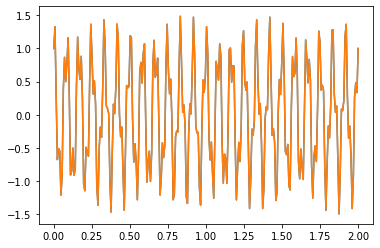

In [50]:
# Inverse transform
y1 = np.fft.ifft(Y)
plt.plot(t, y1.real)
plt.plot(t, y)

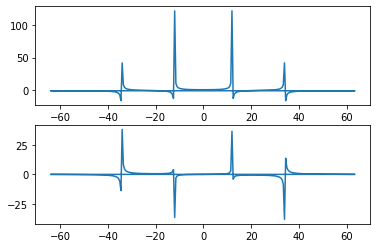

In [47]:
# Negative freq not always needed
plt.subplot(2,1,1); plt.plot(f,Y.real)
plt.subplot(2,1,2); plt.plot(f,Y.imag)

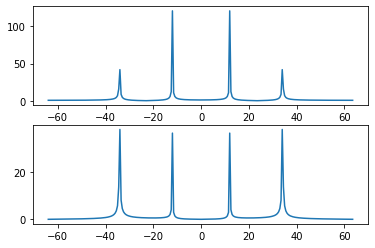

In [48]:
# Reorder array to tidy up plot
Y2 = np.fft.fftshift(Y)
f2 = np.fft.fftshift(f)
plt.subplot(2,1,1); plt.plot(f2, abs(Y2.real))
plt.subplot(2,1,2); plt.plot(f2, abs(Y2.imag));

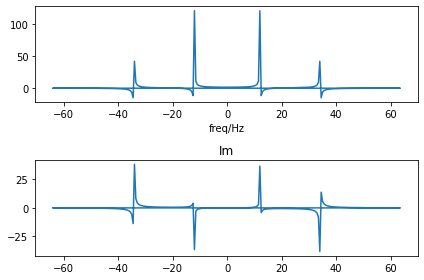

In [49]:
fig, (a,b) = plt.subplots(2)
a.plot(f, Y.real)
b.plot(f, Y.imag)
a.set_xlabel("freq/Hz")
b.set_title("Im")
fig.tight_layout()